# Estimering af den kausale effekt af et forloebsplejeprogram paa 30-dages genindlaeggelse med PROC CAUSALTRT

## Sammenfatning

Denne notebook estimerer den **gennemsnitlige behandlingseffekt (ATE)** af at indskrive udskrevne patienter i et *Care Connect*-overgangsplejeprogram paa sandsynligheden for en genindlaeggelse inden for 30 dage, ved brug af observationsdata hvor mere syge patienter fortrinsvis indskrives. Vi korrigerer for confounding med invers sandsynlighedsvaegtning (IPW), regressionsjustering (REGADJ) og den dobbelt robuste augmenterede IPW (AIPW)-estimator i **PROC CAUSALTRT**, og opnaar bootstrap-konfidensintervaller for effekten. Alle tre estimatorer genfinder en negativ ATE - en reduktion paa cirka 15-21 procentpoint i genindlaeggelsessandsynligheden - selv om den raa sammenligning ser naesten flad ud, fordi den indskrevne gruppe er mere syg.

## Datakilder

Den enkelte syntetiske kohorte `careprog` (100 udskrevne patienter) genereres inline med `call streaminit(20250529)`. Indskrivning i plejeprogrammet er confounded: hoejrisikopatienter (flere komorbiditeter, tidligere indlaeggelser) er mere tilboejelige til at blive indskrevet, og de samme faktorer driver genindlaeggelse, saa en naiv sammenligning er biased. Behandling og udfald er kodet som numeriske 0/1-indikatorer, hvilket er det, `PROC CAUSALTRT` modellerer direkte.

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `PatientID` | Num | Sekventiel patientidentifikator (1-100) |
| `Age` | Num | Alder i aar ved udskrivning (kontinuert confounder) |
| `Comorbidities` | Num | Antal kroniske tilstande, 0-6 (Poisson-trukket confounder) |
| `PriorAdmits` | Num | Hospitalsindlaeggelser i de foregaaende 12 maaneder (confounder) |
| `LOS` | Num | Laengden af det aktuelle hospitalsophold, dage (confounder) |
| `Female` | Num | Koensindikator, 1 = kvinde |
| `Medicare` | Num | Betalerindikator, 1 = Medicare (delvis confounder) |
| `Enrolled` | Num | Behandling: 1 hvis indskrevet i Care Connect, ellers 0 |
| `Readmit30` | Num | Udfald: 1 hvis genindlagt inden for 30 dage, ellers 0 |

# Kausal effekt af et forloebsplejeprogram paa 30-dages genindlaeggelse

Hospitalssystemer straffes for overskydende 30-dages genindlaeggelser, saa mange lancerer **overgangsplejeprogrammer** (medicinafstemning, opfoelgende opkald, planlagte besoeg hos praktiserende laege) for patienter ved udskrivning. Fordi indskrivning *ikke er randomiseret* - sagsbehandlere indskriver fortrinsvis de patienter, de vurderer som de mest syge - er en simpel sammenligning af genindlaeggelsesrater mellem indskrevne og ikke-indskrevne patienter confounded.

`PROC CAUSALTRT` estimerer den **gennemsnitlige behandlingseffekt (ATE)** af en binaer behandling paa et udfald i observationsdata ved brug af:

- **IPW** - invers sandsynlighedsvaegtning (propensity score-vaegtning),
- **REGADJ** - regressionsjustering af udfaldet, og
- **AIPW** - den *dobbelt robuste* augmenterede IPW-estimator, som er konsistent hvis *enten* propensity-modellen *eller* udfaldsmodellen er korrekt specificeret.

I denne notebook opbygger vi en syntetisk udskrivningskohorte med indbygget confounding, viser at det naive estimat er biased, og genfinder derefter den beskyttende effekt med `PROC CAUSALTRT`.

## 1. Generer en syntetisk udskrivningskohorte

Vi simulerer 100 udskrevne patienter. Fire kliniske risikofaktorer - `Age`, `Comorbidities`, `PriorAdmits` og opholdslaengden `LOS` - er sammen med betalerflaget `Medicare` **confoundere**: de oeger baade chancen for at blive indskrevet i Care Connect og chancen for genindlaeggelse.

Den sande programeffekt er indbygget som en reduktion paa **1,3 paa genindlaeggelses-logitten**. En korrekt kausalanalyse boer genfinde en *negativ* ATE (en absolut reduktion paa cirka 15-20 procentpoint), mens en naiv sammenligning vil se meget mindre ud, fordi de mest syge patienter er overrepraesenteret blandt de indskrevne.

In [1]:
data careprog;
  CALL streaminit(20250529);
  GØR PatientID = 1 TIL 100;

    /* ---- Baseline patient characteristics (pre-treatment) ---- */
    AGE           = round(40 + 40*rand("uniform"));      /* 40-80 yrs */
    Comorbidities = rand("poisson", 1.8);                /* chronic conditions */
    HVIS Comorbidities > 6 SÅ Comorbidities = 6;
    PriorAdmits   = rand("poisson", 0.7);                /* admits last 12 mo */
    LOS           = round(2 + rand("poisson", 3));       /* index stay, days */
    Female        = (rand("uniform") < 0.52);            /* 1 = female */
    Medicare      = (rand("uniform") < 0.45);            /* 1 = Medicare payer */

    /* ---- Treatment assignment: case managers enroll sicker patients ---- */
    /* The enrollment propensity increases with every confounder, so the    */
    /* treated and control groups are NOT exchangeable.                     */
    eta_t = -2.6
          + 0.030*AGE
          + 0.45 *Comorbidities
          + 0.55 *PriorAdmits
          + 0.10 *LOS
          + 0.30 *Medicare;
    pEnroll = 1 / (1 + EXP(-eta_t));
    Enrolled = rand("bernoulli", pEnroll);               /* 1 = in Care Connect */

    /* ---- Outcome: 30-day readmission (1 = readmitted) ---- */
    /* Confounders raise readmission risk; the program LOWERS it (true ATE). */
    trueEffect = -1.3;                                   /* program logit effect */
    eta_y = -1.6
          + 0.030*AGE
          + 0.55 *Comorbidities
          + 0.65 *PriorAdmits
          + 0.10 *LOS
          + trueEffect*Enrolled;
    pReadmit = 1 / (1 + EXP(-eta_y));
    Readmit30 = rand("bernoulli", pReadmit);

    UDDATA;
  SLUT;
  FJERN eta_t pEnroll trueEffect eta_y pReadmit;
KØR;


NOTE: DATA careprog


NOTE: Wrote careprog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## 2. Inspicer kohorten og det naive (biased) estimat

Foer nogen kausal justering ser vi paa den raa genindlaeggelsesrate efter indskrivningsstatus. Fordi de mest syge patienter er koncentreret i den indskrevne gruppe, **undervurderer** den ujusterede forskel den sande beskyttende effekt af programmet. `PROC MEANS`-tabellen viser derefter, at de indskrevne og ikke-indskrevne grupper adskiller sig paa confounderne, hvilket motiverer den efterfoelgende justering.

                                Rå (ujusteret) genindlæggelse efter programindskrivning                                 

                                                   The FREQ Procedure

Table of Indskrevet by Genindlagt (30 dage)

Indskrevet |         0 |         1 |      Total
-----------+-----------+-----------+-----------
0          |         4 |        27 |         31
-----------+-----------+-----------+-----------
1          |        20 |        49 |         69
-----------+-----------+-----------+-----------
Total      |        24 |        76 |        100

                          Confounder-fordelinger adskiller sig på tværs af behandlingsgrupper                           

                                                  The MEANS Procedure

                                          Analysis Variable : AGE Alder (år)

        Indskrevet          N Obs           Mean        Minimum        Maximum
        -------------------------------------------------------------------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_enrolled_readmit30.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


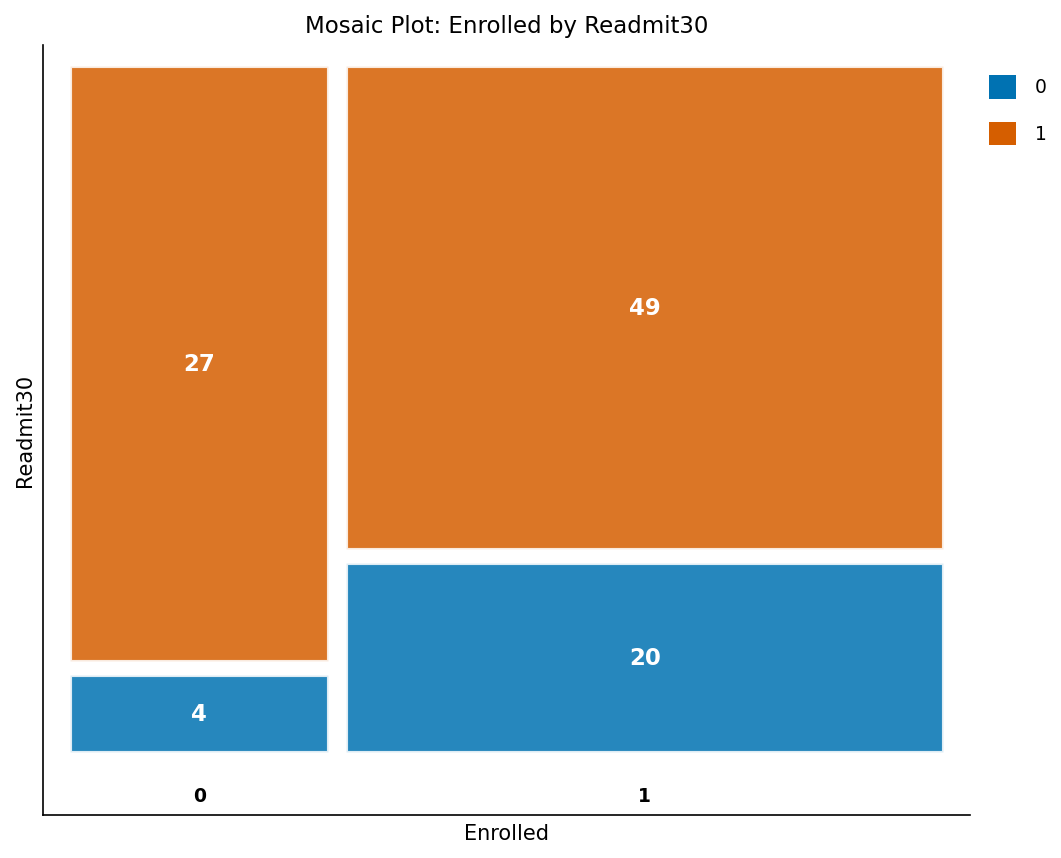

In [2]:
PROCEDURE FREKVENSER data=careprog;
  TABLES Enrolled*Readmit30 / nopercent norow nocol;
  MÆRKAT Enrolled="Indskrevet" Readmit30="Genindlagt (30 dage)";
  TITEL "Rå (ujusteret) genindlæggelse efter programindskrivning";
KØR;

PROCEDURE GENNEMSNIT data=careprog n mean MIN MAX maxdec=2;
  KLASSE Enrolled;
  VARIABEL AGE Comorbidities PriorAdmits LOS;
  MÆRKAT AGE="Alder (år)" Comorbidities="Komorbiditeter"
         PriorAdmits="Tidligere indlæggelser" LOS="Liggetid (dage)"
         Enrolled="Indskrevet";
  TITEL "Confounder-fordelinger adskiller sig på tværs af behandlingsgrupper";
KØR;

## 3. Gennemsnitlig behandlingseffekt via invers sandsynlighedsvaegtning (IPW)

**PSMODEL**-saetningen tilpasser en logistisk propensity score-model for behandlingen (`Enrolled`); **MODEL**-saetningen navngiver det binaere udfald (`Readmit30`). Med `METHOD=IPW` vaegtes hver patient med den inverse sandsynlighed for den behandling, de faktisk modtog, hvilket skaber en pseudo-population, hvor confounderne er balancerede paa tvaers af behandlingsgrupperne.

Baade `Enrolled` og `Readmit30` er numeriske 0/1-indikatorer, saa proceduren modellerer sandsynligheden for indskrivning og for genindlaeggelse direkte. **BOOTSTRAP**-saetningen resampler kohorten for at producere en robust standardfejl og et percentil-konfidensinterval for ATE. Proceduren rapporterer propensity-modellens koefficienter, de potentielle udfaldsgennemsnit under behandling og kontrol samt behandlingseffekten.

In [3]:
PROCEDURE causaltrt data=careprog METHOD=ipw;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  MODEL Readmit30 / DIST=binomial;
  bootstrap nboot=300 seed=20250529;
  TITEL "ATE af Care Connect på 30-dages genindlæggelse - IPW";
KØR;

                          Confounder-fordelinger adskiller sig på tværs af behandlingsgrupper                           


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: IPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.1475  


NOTE: PROC CAUSALTRT data=careprog



## 4. Dobbelt robust estimat (AIPW) med bootstrap-konfidensintervaller

IPW afhaenger af en korrekt propensity-model; regressionsjustering afhaenger af en korrekt udfaldsmodel. Den **augmenterede IPW**-estimator (`METHOD=AIPW`) kombinerer begge og er *dobbelt robust*: den forbliver konsistent hvis **enten** model er korrekt. Vi specificerer derfor kovariater paa baade `PSMODEL` og `MODEL`.

**BOOTSTRAP**-saetningen med `BOOTCI(BC)` resampler kohorten for at producere et **bias-korrigeret** konfidensinterval for behandlingseffekten. Fordi AIPW laener sig op ad begge modeller, er dette det centrale estimat, der skal rapporteres til interessenter.

In [4]:
PROCEDURE causaltrt data=careprog METHOD=aipw;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  MODEL Readmit30 = AGE Comorbidities PriorAdmits LOS Medicare
        / DIST=binomial;
  bootstrap bootci(bc) nboot=300 seed=20250529;
  TITEL "ATE af Care Connect på 30-dages genindlæggelse - AIPW (dobbelt robust)";
KØR;

                          Confounder-fordelinger adskiller sig på tværs af behandlingsgrupper                           


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: AIPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.2011 


NOTE: PROC CAUSALTRT data=careprog



## 5. Kontrol med regressionsjustering (REGADJ)

Som en foelsomhedskontrol estimerer vi den samme ATE med `METHOD=REGADJ`, som danner effekten udelukkende ud fra den tilpassede udfaldsmodel. Vi angiver stadig `PSMODEL`-saetningen (den navngiver behandlingsvariablen), men estimatet drives af udfaldsregressionen snarere end af vaegtene. Taet overensstemmelse mellem IPW, AIPW og REGADJ er betryggende evidens for, at justeringen er stabil og ikke et artefakt af et bestemt modelleringsvalg.

In [5]:
PROCEDURE causaltrt data=careprog METHOD=regadj;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  MODEL Readmit30 = AGE Comorbidities PriorAdmits LOS Medicare
        / DIST=binomial;
  bootstrap nboot=300 seed=20250529;
  TITEL "ATE af Care Connect på 30-dages genindlæggelse - regressionsjustering";
KØR;

                          Confounder-fordelinger adskiller sig på tværs af behandlingsgrupper                           


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: REGADJ
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.207


NOTE: PROC CAUSALTRT data=careprog



## 6. Gem propensity scores og vaegte pr. patient

**OUTPUT**-saetningen skriver hver patients estimerede propensity score og inverse sandsynlighedsvaegt tilbage til et datasaet. Disse er nyttige operationelt: de stoerste vaegte falder paa de ikke-indskrevne patienter, hvis kovariatprofil ligner behandlede (hoej propensity), og meget store vaegte flagger patienter i omraader med daarligere overlap, hvis indflydelse paa estimatet fortjener naermere granskning.

In [6]:
PROCEDURE causaltrt data=careprog METHOD=ipw;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  MODEL Readmit30 / DIST=binomial;
  UDDATA out=careprog_ps pscore=PropScore ipw=IPWeight;
KØR;

PROCEDURE UDSKRIV data=careprog_ps(obs=8) noobs;
  VARIABEL PatientID Enrolled Readmit30 PropScore IPWeight;
  MÆRKAT PatientID="Patient-id" Enrolled="Indskrevet"
         Readmit30="Genindlagt (30 dage)" PropScore="Propensity score"
         IPWeight="IP-vægt";
  TITEL "Estimerede propensity scores og IP-vægte (første 8 patienter)";
KØR;

PROCEDURE GENNEMSNIT data=careprog_ps n mean p95 MAX maxdec=3;
  KLASSE Enrolled;
  VARIABEL PropScore IPWeight;
  MÆRKAT PropScore="Propensity score" IPWeight="IP-vægt" Enrolled="Indskrevet";
  TITEL "Vægtfordeling efter behandlingsgruppe (hold øje med ekstreme vægte)";
KØR;

                          Confounder-fordelinger adskiller sig på tværs af behandlingsgrupper                           


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: IPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.1475  


NOTE: PROC CAUSALTRT data=careprog

NOTE: CAUSALTRT OUTPUT dataset careprog_ps written.
NOTE: PROC PRINT data=careprog_ps

NOTE: PROC PRINT completed: 8 observations printed, 5 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 7. Fortolkning af resultaterne

- **Confounding er reel.** Den raa optaelling i trin 2 viser den *ikke-indskrevne* gruppe med en let hoejere raa genindlaeggelsesrate, men forskellen er langt mindre end programmets sande effekt, fordi sagsbehandlere indskrev de mest syge patienter. `PROC MEANS` efter `Enrolled` bekraefter, at den indskrevne gruppe baerer flere komorbiditeter og tidligere indlaeggelser end den ikke-indskrevne gruppe.
- **Alle tre kausale estimatorer er enige.** Efter justering for de maalte confoundere genfinder IPW, AIPW og REGADJ hver en **negativ ATE** - en reduktion i 30-dages genindlaeggelsessandsynligheden paa cirka 15-21 procentpoint - i overensstemmelse med den beskyttende effekt, der er indbygget i simuleringen (et `-1.3`-skift paa genindlaeggelses-logitten). Behandlingseffekt-raekken rapporterer punktestimatet, bootstrap-standardfejlen og konfidensgraenserne.
- **Dobbelt robust er det centrale estimat.** Fordi AIPW er konsistent hvis *enten* propensity- eller udfaldsmodellen er korrekt, er dens bootstrap-bias-korrigerede konfidensinterval den mest forsvarlige stoerrelse at rapportere. Her udelukker dette interval nul, saa den beskyttende effekt er statistisk skelnelig fra ingen effekt ved denne stikproevestoerrelse.
- **Overlap er rimeligt.** De gemte propensity scores viser den indskrevne gruppe ved hoejere gennemsnitlig propensity end den ikke-indskrevne gruppe, og de inverse sandsynlighedsvaegte er stoerst for de ikke-indskrevne, behandlingslignende patienter - praecis hvor data er tyndest. Ingen enkelt vaegt dominerer analysen.

**Konklusion for sundhedssystemet:** under antagelsen om ingen umaalt confounding *saenker* indskrivning af udskrevne patienter i Care Connect *kausalt* 30-dages genindlaeggelsesraten, hvilket understoetter en udvidelse af programmet. OUTPUT-datasaettet lader desuden analytikere flagge patienter med ekstreme vaegte, hvis case-mix ligger uden for omraadet med godt overlap.

> **Forbehold:** `PROC CAUSALTRT` justerer kun for *maalte* confoundere. Gyldigheden af disse estimater hviler paa antagelsen om, at ingen vigtig umaalt faktor (f.eks. social stoette, baseline-skroebelighed der ikke er indfanget her) faelles driver baade indskrivning og genindlaeggelse. Med kun 100 patienter er konfidensintervallerne brede, saa punktestimaterne boer laeses som illustrative snarere end definitive.